In [738]:
import pandas as pd

In [739]:
df = pd.read_csv("./vodafone_age_subset.csv", sep=",")
df.head()

,CALCULATION_METHOD_ID,calls_count_in_weekdays,calls_duration_in_weekdays,calls_count_out_weekdays,calls_duration_out_weekdays,calls_count_in_weekends,calls_duration_in_weekends,calls_count_out_weekends,calls_duration_out_weekends,DATA_VOLUME_WEEKDAYS,...,applemaps_volume,applemaps_count,msoffice365_volume,msoffice365_count,jabber_volume,jabber_count,telegram_volume,telegram_count,user_hash,target
0,2,10.87,32.025,17.74,40.819,7.00,21.463,11.13,20.427,154.837,...,0.0,0.0,0.09,9.29,0.0000,0.0,0.0,0.0,312ca09052ac6eb49fbd2a546a782df5,4
1,1,0.91,1.346,0.48,0.546,0.25,0.688,0.75,0.708,53.639,...,0.0,0.0,0.00,0.00,0.0033,0.1,0.0,0.0,327733ea2cea082b48707d2700b49327,4
2,2,0.00,0.000,0.00,0.000,0.00,0.000,0.00,0.000,0.000,...,0.0,0.0,0.00,0.00,0.0000,0.0,0.0,0.0,22ede60385359c8c24bc68449ca56763,6
3,2,7.39,30.278,11.00,44.182,5.00,20.008,8.38,32.385,0.000,...,0.0,0.0,0.00,0.00,0.0000,0.0,0.0,0.0,67682b3b1d1319a7cf90ed80eb16b899,5
4,1,0.43,0.996,0.70,1.609,2.25,3.115,0.00,0.000,0.000,...,0.0,0.0,0.00,0.00,0.0000,0.0,0.0,0.0,334e5ceddcc4f11f261322832526ae49,3


In [740]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Columns: 116 entries, CALCULATION_METHOD_ID to target
dtypes: float64(97), int64(5), object(14)
memory usage: 18.6+ MB


In [741]:
print(df.isna().sum()[df.isna().sum() > 0])

Series([], dtype: int64)


In [742]:
df = df.drop('user_hash', axis=1)

In [743]:
df = df.drop('CALCULATION_METHOD_ID', axis=1)

In [744]:
print(df['software_os_vendor'].value_counts())

software_os_vendor
Google         11788
0               3458
Apple           2597
Nokia           1772
Samsung          770
Microsoft        243
Symbian          174
Alibaba           83
Enea              48
Mentor Grap       27
Blackberry        14
Spreadtrum        12
Mediatek          10
Palm               3
MeeGo              1
Name: count, dtype: int64


In [745]:
print(df['device_model'].value_counts())

device_model
0                    1779
Redmi 4X              419
iPhone 6S (A1688)     316
SM-J510H DS           291
iPhone 7 (A1778)      267
                     ... 
SM-N910F                1
SM-J810F DS             1
Xperia SP M35h          1
MI 3                    1
SGH-B320                1
Name: count, Length: 2114, dtype: int64


In [746]:
df = df.drop(columns='device_model', axis=1)

In [747]:
print(len(df['Oblast_post_HOME'].unique()))

29


In [748]:
print(len(df['Raion_post_HOME'].unique()))

495


In [749]:
print(len(df['City_post_HOME'].unique()))

1659


In [750]:
target_values = [0, '0']

mask = (
    df['Oblast_post_HOME'].isin(target_values) &
    df['Raion_post_HOME'].isin(target_values)
)

print(mask.sum())

1295


In [751]:
df = df[df['Oblast_post_HOME'] != '0']

In [752]:
print(df.columns)

Index(['calls_count_in_weekdays', 'calls_duration_in_weekdays',
       'calls_count_out_weekdays', 'calls_duration_out_weekdays',
       'calls_count_in_weekends', 'calls_duration_in_weekends',
       'calls_count_out_weekends', 'calls_duration_out_weekends',
       'DATA_VOLUME_WEEKDAYS', 'DATA_VOLUME_WEEKENDS',
       ...
       'netflix_count', 'applemaps_volume', 'applemaps_count',
       'msoffice365_volume', 'msoffice365_count', 'jabber_volume',
       'jabber_count', 'telegram_volume', 'telegram_count', 'target'],
      dtype='object', length=113)


In [753]:
df = df[df['software_os_vendor'] != '0']
df = df[df['software_os_vendor'] != 0]

In [754]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16794 entries, 0 to 20999
Columns: 113 entries, calls_count_in_weekdays to target
dtypes: float64(97), int64(4), object(12)
memory usage: 14.6+ MB


In [755]:
df['software_os_name'].value_counts()

software_os_name
Android        11357
iOS             2481
40              1027
0                719
30               541
Win Pho          197
Asha              94
YunOS             81
60.5              51
Bada              39
OSE               38
60.3.2            37
Windows           22
Anna              21
Nucleus           20
60.3.1            20
CyanogenMod       13
60.3              10
Belle              6
60.2.3             5
60.2.2             4
Win Mob            4
60.2.1             2
Garnet             2
UIQ 2.1            1
Linux              1
UIQ 3.0            1
Name: count, dtype: int64

In [756]:
target_os = ['Android', 'iOS']

df = df[df['software_os_name'].isin(target_os)]

print(df['software_os_name'].value_counts())

software_os_name
Android    11357
iOS         2481
Name: count, dtype: int64


In [757]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13838 entries, 0 to 20999
Columns: 113 entries, calls_count_in_weekdays to target
dtypes: float64(97), int64(4), object(12)
memory usage: 12.0+ MB


In [758]:
df['sim_count'].value_counts()

sim_count
2.0    5292
0.0    5138
1.0    3397
3.0       6
4.0       5
Name: count, dtype: int64

In [759]:
print(df[df['sim_count'] == 0]['software_os_name'].value_counts())

software_os_name
Android    4498
iOS         640
Name: count, dtype: int64


In [760]:
df.loc[df['sim_count'] > 2, 'sim_count'] = 2.0

mask_android_zero = (df['software_os_name'] == 'Android') & (df['sim_count'] == 0)
df.loc[mask_android_zero, 'sim_count'] = 2.0

mask_ios_zero = (df['software_os_name'] == 'iOS') & (df['sim_count'] == 0)
df.loc[mask_ios_zero, 'sim_count'] = 1.0

print(df['sim_count'].value_counts())

sim_count
2.0    9801
1.0    4037
Name: count, dtype: int64


In [761]:
df['software_os_version'].value_counts()

software_os_version
5.1        2594
6.0        2257
0          1726
7.0        1264
4.4        1064
7.1         833
8.0         606
4.2         502
10          485
9.0         408
4.1         383
11          337
5.0         320
4.0         182
6           182
2.3         156
4.3         148
9.3         108
5           101
4            70
2.2          50
8.1          21
2.1          18
0.0           9
10.4.10       4
1.6           4
10.0          3
11.0          1
3.0           1
10.4.8        1
Name: count, dtype: int64

In [762]:
def standardize_version(val):
    val = str(val).strip()

    if val in ['0', '0.0', 'nan', 'None', '']:
        return np.nan

    parts = val.split('.')
    if len(parts) >= 2:
        return f"{parts[0]}.{parts[1]}"

    return f"{parts[0]}.0"

df['software_os_version'] = df['software_os_version'].apply(standardize_version)

mode_val = df['software_os_version'].mode()[0]
df['software_os_version'] = df['software_os_version'].fillna(mode_val)


df['software_os_version'] = df['software_os_version'].astype(float)
print(df['software_os_version'].value_counts())

software_os_version
5.1     4329
6.0     2439
7.0     1264
4.4     1064
7.1      833
8.0      606
4.2      502
10.0     488
5.0      421
9.0      408
4.1      383
11.0     338
4.0      252
2.3      156
4.3      148
9.3      108
2.2       50
8.1       21
2.1       18
10.4       5
1.6        4
3.0        1
Name: count, dtype: int64


In [763]:
df['device_type_rus'].value_counts()

device_type_rus
smartphone    13837
phone             1
Name: count, dtype: int64

In [764]:
df = df.drop(columns='device_type_rus', axis=1)

In [765]:
df['SHELL'].value_counts()

SHELL
0.0     13621
2.0       113
4.0        36
5.0        10
6.0        10
8.0        10
1.0        10
10.0        5
7.0         4
14.0        3
3.0         3
23.0        2
26.0        1
17.0        1
11.0        1
41.0        1
50.0        1
28.0        1
33.0        1
19.0        1
13.0        1
27.0        1
20.0        1
Name: count, dtype: int64

In [766]:
df['gas_stations_sms'].value_counts()

gas_stations_sms
0.0      11080
1.0        655
2.0        426
3.0        307
4.0        234
5.0        199
6.0        141
7.0        120
9.0        113
8.0        101
10.0        89
11.0        79
12.0        51
13.0        39
15.0        32
14.0        26
16.0        25
17.0        16
18.0        12
20.0        12
22.0        10
25.0         7
19.0         7
24.0         6
21.0         6
26.0         5
28.0         4
23.0         3
34.0         3
33.0         3
27.0         2
35.0         2
45.0         2
29.0         2
32.0         2
58.0         1
49.0         1
41.0         1
30.0         1
36.0         1
44.0         1
66.0         1
131.0        1
71.0         1
56.0         1
31.0         1
48.0         1
47.0         1
42.0         1
50.0         1
65.0         1
80.0         1
Name: count, dtype: int64

In [767]:
fuel_columns = ['OKKO', 'SHELL', 'SUNOIL', 'KLO', 'BRSM', 'AMIC', 'TNK', 'UPG']

df['Brands_Sum'] = df[fuel_columns].fillna(0).sum(axis=1)

df['Fuel_Activity_Score'] = df[['gas_stations_sms', 'Brands_Sum']].max(axis=1)

df['Is_Driver'] = (df['Fuel_Activity_Score'] > 0).astype(int)

cols_to_drop = fuel_columns + ['gas_stations_sms', 'Brands_Sum']
df = df.drop(columns=cols_to_drop)

df['Fuel_Activity_Score'].value_counts()

Fuel_Activity_Score
0.0      11080
1.0        655
2.0        426
3.0        307
4.0        234
5.0        199
6.0        141
7.0        120
9.0        113
8.0        101
10.0        89
11.0        79
12.0        51
13.0        39
15.0        32
14.0        26
16.0        25
17.0        16
18.0        12
20.0        12
22.0        10
25.0         7
19.0         7
24.0         6
21.0         6
26.0         5
28.0         4
23.0         3
34.0         3
33.0         3
27.0         2
35.0         2
45.0         2
29.0         2
32.0         2
58.0         1
49.0         1
41.0         1
30.0         1
36.0         1
44.0         1
66.0         1
131.0        1
71.0         1
56.0         1
31.0         1
48.0         1
47.0         1
42.0         1
50.0         1
65.0         1
80.0         1
Name: count, dtype: int64

In [768]:
df.columns

Index(['calls_count_in_weekdays', 'calls_duration_in_weekdays',
       'calls_count_out_weekdays', 'calls_duration_out_weekdays',
       'calls_count_in_weekends', 'calls_duration_in_weekends',
       'calls_count_out_weekends', 'calls_duration_out_weekends',
       'DATA_VOLUME_WEEKDAYS', 'DATA_VOLUME_WEEKENDS',
       ...
       'applemaps_count', 'msoffice365_volume', 'msoffice365_count',
       'jabber_volume', 'jabber_count', 'telegram_volume', 'telegram_count',
       'target', 'Fuel_Activity_Score', 'Is_Driver'],
      dtype='object', length=105)

In [769]:
target_cols = [col for col in df.columns if 'volume' in col.lower() or 'count' in col.lower()]

print(f"Найдено колонок: {len(target_cols)}")

for col in target_cols:
    print(f"\n{'='*20} {col} {'='*20}")

    zeros_count = df[df[col].isin([0, '0', 0.0])].shape[0]
    zeros_pct = (zeros_count / len(df)) * 100

    print(f"Процент нулей: {zeros_pct:.2f}%")
    print("-" * 10)

    print(df[col].value_counts(dropna=False).head(15))

Найдено колонок: 58

==================== calls_count_in_weekdays ====================
Процент нулей: 2.37%
----------
calls_count_in_weekdays
0.00    328
0.04    124
1.91    101
0.09     85
0.35     84
0.48     83
0.13     83
0.30     82
0.52     82
1.22     82
0.96     81
2.74     81
2.70     80
0.17     79
1.83     79
Name: count, dtype: int64

==================== calls_count_out_weekdays ====================
Процент нулей: 3.82%
----------
calls_count_out_weekdays
0.00    529
0.04    163
0.09    135
0.13    102
0.26     95
0.17     90
2.17     89
0.39     85
0.61     81
0.87     81
1.87     80
0.35     80
1.13     78
0.43     77
2.35     77
Name: count, dtype: int64

==================== calls_count_in_weekends ====================
Процент нулей: 6.01%
----------
calls_count_in_weekends
0.00    832
0.13    394
0.75    365
1.13    352
0.88    350
0.38    346
1.00    342
0.25    342
0.50    329
1.63    321
0.63    320
1.50    317
1.75    311
1.38    306
1.25    303
Name: count, dtyp

In [770]:
base_names = set([c.replace('_volume', '').replace('_count', '')
                  for c in df.columns if '_volume' in c or '_count' in c])

cols_to_drop = []

print("Анализ корреляции Volume vs Count:")
for base in base_names:
    vol_col = f"{base}_volume"
    cnt_col = f"{base}_count"

    if vol_col in df.columns and cnt_col in df.columns:
        corr = df[[vol_col, cnt_col]].corr().iloc[0, 1]
        print(f"{base}: корреляция {corr:.4f}")

        if corr > 0.9:
            cols_to_drop.append(cnt_col)

print(f"\nБудет удалено {len(cols_to_drop)} дублирующих колонок Count.")
df = df.drop(columns=cols_to_drop)

gamers_cols = ['steam_volume', 'twitch_volume']
available_gamers = [c for c in gamers_cols if c in df.columns]
if available_gamers:
    df['Gamer_Score'] = df[available_gamers].sum(axis=1)
    df['Is_Gamer'] = (df['Gamer_Score'] > 0).astype(int)

dating_cols = ['tinder_volume', 'badoo_volume']
available_dating = [c for c in dating_cols if c in df.columns]
if available_dating:
    df['Dating_App_User'] = (df[available_dating].sum(axis=1) > 0).astype(int)

work_cols = ['linkedin_volume', 'msoffice365_volume', 'dropbox_volume']
available_work = [c for c in work_cols if c in df.columns]
if available_work:
    df['White_Collar_Worker'] = (df[available_work].sum(axis=1) > 0).astype(int)

taxi_cols = ['uber_volume']
available_taxi = [c for c in taxi_cols if c in df.columns]
if available_taxi:
    df['Taxi_User'] = (df[available_taxi].sum(axis=1) > 0).astype(int)

geek_cols = ['jabber_volume', 'tumblr_volume', 'flickr_volume', 'snapchat_volume']
available_geek = [c for c in geek_cols if c in df.columns]
if available_geek:
    df['Niche_Social_User'] = (df[available_geek].sum(axis=1) > 0).astype(int)

expensive_cols = ['netflix_volume', 'itunes_volume']
available_rich = [c for c in geek_cols if c in df.columns]
if available_rich:
    df['Paid_Content_User'] = (df[available_rich].sum(axis=1) > 0).astype(int)

rare_cols_to_remove = available_gamers + available_dating + available_work + available_taxi + available_geek
df = df.drop(columns=rare_cols_to_remove)

print("\nОбработка завершена.")
print("Новые колонки:", ['Is_Gamer', 'Dating_App_User', 'White_Collar_Worker', 'Taxi_User', 'Niche_Social_User', 'Paid_Content_User'])

Анализ корреляции Volume vs Count:
jabber: корреляция 0.6791
skype: корреляция 0.1375
viber: корреляция 0.8177
fb: корреляция 0.6477
gmail: корреляция 0.4377
google: корреляция 0.4728
applemaps: корреляция 0.7583
uber: корреляция 0.9264
steam: корреляция 0.6674
flickr: корреляция 0.4715
itunes: корреляция 0.7449
snapchat: корреляция 0.8360
youtube: корреляция 0.7445
linkedin: корреляция 0.6906
tumblr: корреляция 0.6965
badoo: корреляция 0.8842
dropbox: корреляция 0.5367
tinder: корреляция 0.9377
msoffice365: корреляция 0.4930
twitch: корреляция 0.8282
whatsapp: корреляция 0.3018
twitter: корреляция 0.8258
telegram: корреляция 0.3866
netflix: корреляция 0.8609

Будет удалено 2 дублирующих колонок Count.

Обработка завершена.
Новые колонки: ['Is_Gamer', 'Dating_App_User', 'White_Collar_Worker', 'Taxi_User', 'Niche_Social_User', 'Paid_Content_User']


In [771]:
aggregated_apps = [
    'steam', 'twitch',
    'tinder', 'badoo',
    'linkedin', 'msoffice365','dropbox',
    'uber',
    'jabber', 'tumblr', 'flickr', 'snapchat',
    'netflix', 'itunes'
]

cols_to_cleanup = [c for c in df.columns if any(c.startswith(app) for p in aggregated_apps for app in [p])]

df = df.drop(columns=cols_to_cleanup, errors='ignore')

In [772]:
df.columns

Index(['calls_count_in_weekdays', 'calls_duration_in_weekdays',
       'calls_count_out_weekdays', 'calls_duration_out_weekdays',
       'calls_count_in_weekends', 'calls_duration_in_weekends',
       'calls_count_out_weekends', 'calls_duration_out_weekends',
       'DATA_VOLUME_WEEKDAYS', 'DATA_VOLUME_WEEKENDS', 'LAT_HOME', 'LON_HOME',
       'Oblast_post_HOME', 'Raion_post_HOME', 'City_post_HOME',
       'lat_quad_home', 'lon_quad_home', 'LAT_WORK', 'LON_WORK',
       'Oblast_post_WORK', 'Raion_post_WORK', 'City_post_WORK',
       'lat_quad_work', 'lon_quad_work', 'device_brand', 'software_os_vendor',
       'software_os_name', 'software_os_version', 'sim_count', 'AVG_ARPU',
       'ROUM', 'phone_value', 'SCORING', 'car', 'gender', 'lifetime',
       'how_long_same_model', 'ecommerce_score', 'PRIVAT', 'OSCHADBANK',
       'ALFABANK', 'UKRSOTBANK', 'OTP', 'UKRGASBANK', 'RAIFFEISEN',
       'PIVDENNYI', 'IDEABANK', 'SBERBANK', 'MONOBANK', 'PRAVEXBANK', 'UKRSIB',
       'banks_sms_count

In [773]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13838 entries, 0 to 20999
Data columns (total 84 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   calls_count_in_weekdays      13838 non-null  float64
 1   calls_duration_in_weekdays   13838 non-null  float64
 2   calls_count_out_weekdays     13838 non-null  float64
 3   calls_duration_out_weekdays  13838 non-null  float64
 4   calls_count_in_weekends      13838 non-null  float64
 5   calls_duration_in_weekends   13838 non-null  float64
 6   calls_count_out_weekends     13838 non-null  float64
 7   calls_duration_out_weekends  13838 non-null  float64
 8   DATA_VOLUME_WEEKDAYS         13838 non-null  float64
 9   DATA_VOLUME_WEEKENDS         13838 non-null  float64
 10  LAT_HOME                     13838 non-null  float64
 11  LON_HOME                     13838 non-null  float64
 12  Oblast_post_HOME             13838 non-null  object 
 13  Raion_post_HOME      

In [774]:
bank_cols = ['PRIVAT', 'OSCHADBANK', 'ALFABANK', 'UKRSOTBANK', 'OTP',
             'UKRGASBANK', 'RAIFFEISEN', 'PIVDENNYI', 'IDEABANK',
             'SBERBANK', 'MONOBANK', 'PRAVEXBANK', 'UKRSIB']

results = []

for col in bank_cols:
    total_sms = df[col].sum()

    users_count = (df[col] > 0).sum()

    results.append({
        'Bank': col,
        'Total_SMS_Volume': total_sms,
        'Unique_Users': users_count
    })

bank_stats = pd.DataFrame(results).sort_values(by='Unique_Users', ascending=False)

print(bank_stats)

          Bank  Total_SMS_Volume  Unique_Users
0       PRIVAT          135641.0          8025
1   OSCHADBANK           64160.0          2162
2     ALFABANK           34928.0          1851
6   RAIFFEISEN           75572.0          1227
10    MONOBANK            2120.0           636
4          OTP           21447.0           576
12      UKRSIB           10151.0           435
5   UKRGASBANK           12559.0           336
3   UKRSOTBANK            8392.0           271
8     IDEABANK            3109.0           252
7    PIVDENNYI            3365.0           154
11  PRAVEXBANK             161.0            11
9     SBERBANK               0.0             0


In [775]:
if 'SBERBANK' in df.columns:
    df = df.drop(columns=['SBERBANK'])

bank_cols = ['PRIVAT', 'OSCHADBANK', 'ALFABANK', 'UKRSOTBANK', 'OTP',
             'UKRGASBANK', 'RAIFFEISEN', 'PIVDENNYI', 'IDEABANK',
             'MONOBANK', 'PRAVEXBANK', 'UKRSIB']

df['Banks_Calculated_Sum'] = df[bank_cols].sum(axis=1)
df['Financial_Activity_Score'] = df[['banks_sms_count', 'Banks_Calculated_Sum']].max(axis=1)
df['Bank_Diversity'] = (df[bank_cols] > 0).sum(axis=1)

df['Has_Privat'] = (df['PRIVAT'] > 0).astype(int)
df['Has_Oschad'] = (df['OSCHADBANK'] > 0).astype(int)
df['Has_Alfa'] = (df['ALFABANK'] > 0).astype(int)
df['Has_Raiffeisen'] = (df['RAIFFEISEN'] > 0).astype(int)

cols_to_drop = bank_cols + ['banks_sms_count', 'Banks_Calculated_Sum']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Новые колонки созданы:")
print(df[['Financial_Activity_Score', 'Bank_Diversity', 'Has_Privat', 'Has_Oschad', 'Has_Alfa', 'Has_Raiffeisen']].head())
print("\nКоличество мульти-банковских клиентов:")
print(df['Bank_Diversity'].value_counts().sort_index())

Новые колонки созданы:
   Financial_Activity_Score  Bank_Diversity  Has_Privat  Has_Oschad  Has_Alfa  \
0                       0.0               0           0           0         0   
1                       3.0               2           1           0         1   
4                       0.0               0           0           0         0   
5                     189.0               1           1           0         0   
8                      48.0               3           1           0         1   

   Has_Raiffeisen  
0               0  
1               0  
4               0  
5               0  
8               0  

Количество мульти-банковских клиентов:
Bank_Diversity
0    3666
1    5922
2    3081
3     887
4     226
5      50
6       5
7       1
Name: count, dtype: int64


In [776]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13838 entries, 0 to 20999
Data columns (total 76 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   calls_count_in_weekdays      13838 non-null  float64
 1   calls_duration_in_weekdays   13838 non-null  float64
 2   calls_count_out_weekdays     13838 non-null  float64
 3   calls_duration_out_weekdays  13838 non-null  float64
 4   calls_count_in_weekends      13838 non-null  float64
 5   calls_duration_in_weekends   13838 non-null  float64
 6   calls_count_out_weekends     13838 non-null  float64
 7   calls_duration_out_weekends  13838 non-null  float64
 8   DATA_VOLUME_WEEKDAYS         13838 non-null  float64
 9   DATA_VOLUME_WEEKENDS         13838 non-null  float64
 10  LAT_HOME                     13838 non-null  float64
 11  LON_HOME                     13838 non-null  float64
 12  Oblast_post_HOME             13838 non-null  object 
 13  Raion_post_HOME      

In [777]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2) * np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

df['Commute_Distance_KM'] = haversine_distance(
    df['LAT_HOME'].fillna(0), df['LON_HOME'].fillna(0),
    df['LAT_WORK'].fillna(0), df['LON_WORK'].fillna(0)
)

In [778]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13838 entries, 0 to 20999
Data columns (total 77 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   calls_count_in_weekdays      13838 non-null  float64
 1   calls_duration_in_weekdays   13838 non-null  float64
 2   calls_count_out_weekdays     13838 non-null  float64
 3   calls_duration_out_weekdays  13838 non-null  float64
 4   calls_count_in_weekends      13838 non-null  float64
 5   calls_duration_in_weekends   13838 non-null  float64
 6   calls_count_out_weekends     13838 non-null  float64
 7   calls_duration_out_weekends  13838 non-null  float64
 8   DATA_VOLUME_WEEKDAYS         13838 non-null  float64
 9   DATA_VOLUME_WEEKENDS         13838 non-null  float64
 10  LAT_HOME                     13838 non-null  float64
 11  LON_HOME                     13838 non-null  float64
 12  Oblast_post_HOME             13838 non-null  object 
 13  Raion_post_HOME      

In [779]:
df['City_post_HOME'] = df['City_post_HOME'].astype(str).str.lower().str.strip()

big_cities = [
    'київ', 'kyiv', 'kiev',
    'харків', 'kharkiv',
    'одеса', 'odesa', 'odessa',
    'дніпро', 'dnipro', 'dnepropetrovsk',
    'львів', 'lviv',
    'запоріжжя', 'zaporizhzhia'
]

df['Is_Big_City'] = df['City_post_HOME'].isin(big_cities).astype(int)

city_counts = df['City_post_HOME'].value_counts()
df['City_Population_Proxy'] = df['City_post_HOME'].map(city_counts)

raion_counts = df['Raion_post_HOME'].astype(str).value_counts()
df['Raion_Density'] = df['Raion_post_HOME'].astype(str).map(raion_counts)

df = df.drop(columns=['City_post_HOME', 'Raion_post_HOME'])

# --- Проверка ---
print(df[['Is_Big_City', 'City_Population_Proxy', 'Raion_Density']].head(10))

    Is_Big_City  City_Population_Proxy  Raion_Density
0             0                      8             39
1             1                    565            569
4             0                     21             23
5             1                   1119           1119
8             0                    208            208
11            0                      5              5
12            0                    332            345
13            0                    128            133
14            1                    565            569
15            0                      2              3


In [780]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13838 entries, 0 to 20999
Data columns (total 78 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   calls_count_in_weekdays      13838 non-null  float64
 1   calls_duration_in_weekdays   13838 non-null  float64
 2   calls_count_out_weekdays     13838 non-null  float64
 3   calls_duration_out_weekdays  13838 non-null  float64
 4   calls_count_in_weekends      13838 non-null  float64
 5   calls_duration_in_weekends   13838 non-null  float64
 6   calls_count_out_weekends     13838 non-null  float64
 7   calls_duration_out_weekends  13838 non-null  float64
 8   DATA_VOLUME_WEEKDAYS         13838 non-null  float64
 9   DATA_VOLUME_WEEKENDS         13838 non-null  float64
 10  LAT_HOME                     13838 non-null  float64
 11  LON_HOME                     13838 non-null  float64
 12  Oblast_post_HOME             13838 non-null  object 
 13  lat_quad_home        

In [781]:
total_calls = df['calls_count_in_weekdays'] + df['calls_count_out_weekdays'] + \
              df['calls_count_in_weekends'] + df['calls_count_out_weekends']

df['Weekend_Calls_Share'] = (df['calls_count_in_weekends'] + df['calls_count_out_weekends']) / (total_calls + 0.001)

total_data = df['DATA_VOLUME_WEEKDAYS'] + df['DATA_VOLUME_WEEKENDS']
df['Weekend_Data_Share'] = df['DATA_VOLUME_WEEKENDS'] / (total_data + 0.001)

df['Avg_Call_Duration_Weekdays'] = (df['calls_duration_in_weekdays'] + df['calls_duration_out_weekdays']) / \
                                   (df['calls_count_in_weekdays'] + df['calls_count_out_weekdays'] + 0.001)

df['Avg_Call_Duration_Weekends'] = (df['calls_duration_in_weekends'] + df['calls_duration_out_weekends']) / \
                                   (df['calls_count_in_weekends'] + df['calls_count_out_weekends'] + 0.001)

df['Digital_Introvert_Score'] = total_data / (total_calls + 1)

cols_to_drop = ['calls_duration_in_weekdays', 'calls_duration_out_weekdays',
                'calls_duration_in_weekends', 'calls_duration_out_weekends']

df = df.drop(columns=cols_to_drop)

print("Поведенческие фичи созданы. Колонки duration удалены.")
print(df[['Weekend_Calls_Share', 'Avg_Call_Duration_Weekdays', 'Digital_Introvert_Score']].head())

Поведенческие фичи созданы. Колонки duration удалены.
   Weekend_Calls_Share  Avg_Call_Duration_Weekdays  Digital_Introvert_Score
0             0.387882                    2.546014                 7.037704
1             0.418235                    1.360173                30.279646
4             0.665484                    2.303271                 0.000000
5             0.379575                    5.380397                 4.337599
8             0.225186                    1.363707                 6.306220


In [782]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13838 entries, 0 to 20999
Data columns (total 79 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   calls_count_in_weekdays     13838 non-null  float64
 1   calls_count_out_weekdays    13838 non-null  float64
 2   calls_count_in_weekends     13838 non-null  float64
 3   calls_count_out_weekends    13838 non-null  float64
 4   DATA_VOLUME_WEEKDAYS        13838 non-null  float64
 5   DATA_VOLUME_WEEKENDS        13838 non-null  float64
 6   LAT_HOME                    13838 non-null  float64
 7   LON_HOME                    13838 non-null  float64
 8   Oblast_post_HOME            13838 non-null  object 
 9   lat_quad_home               13838 non-null  float64
 10  lon_quad_home               13838 non-null  float64
 11  LAT_WORK                    13838 non-null  float64
 12  LON_WORK                    13838 non-null  float64
 13  Oblast_post_WORK            13838 no

In [783]:
mapping = {'Google': 1, 'Apple': 0}
df['software_os_vendor'] = df['software_os_vendor'].map(mapping)
df['software_os_vendor'].value_counts()

software_os_vendor
1    11357
0     2481
Name: count, dtype: int64

In [784]:
mapping = {'Android': 1, 'iOS': 0}
df['software_os_name'] = df['software_os_name'].map(mapping)
df['software_os_name'].value_counts()

software_os_name
1    11357
0     2481
Name: count, dtype: int64

In [785]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13838 entries, 0 to 20999
Data columns (total 79 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   calls_count_in_weekdays     13838 non-null  float64
 1   calls_count_out_weekdays    13838 non-null  float64
 2   calls_count_in_weekends     13838 non-null  float64
 3   calls_count_out_weekends    13838 non-null  float64
 4   DATA_VOLUME_WEEKDAYS        13838 non-null  float64
 5   DATA_VOLUME_WEEKENDS        13838 non-null  float64
 6   LAT_HOME                    13838 non-null  float64
 7   LON_HOME                    13838 non-null  float64
 8   Oblast_post_HOME            13838 non-null  object 
 9   lat_quad_home               13838 non-null  float64
 10  lon_quad_home               13838 non-null  float64
 11  LAT_WORK                    13838 non-null  float64
 12  LON_WORK                    13838 non-null  float64
 13  Oblast_post_WORK            13838 no

In [786]:
df['device_brand'].value_counts()

device_brand
Samsung           3726
Apple             2481
Xiaomi            2453
Lenovo            1041
Huawei             838
                  ... 
Symphony             1
MyPhone              1
Minte Telecom        1
Taidian              1
Jurong Hi-Tech       1
Name: count, Length: 130, dtype: int64

In [787]:
import pandas as pd

top_brands = ['Samsung', 'Apple', 'Xiaomi', 'Lenovo', 'Huawei']

df['device_brand_group'] = df['device_brand'].apply(lambda x: x if x in top_brands else 'Other')

df = pd.get_dummies(df, columns=['device_brand_group'], prefix='Brand', dtype=int)

df = df.drop(columns=['device_brand'])

if 'Brand_Apple' in df.columns:
    df = df.drop(columns=['Brand_Apple'])

In [788]:
df['SCORING'].value_counts()

SCORING
HIGH_MEDIUM    4678
MEDIUM         3397
LOW            3393
HIGH           2368
0                 1
VERY LOW          1
Name: count, dtype: int64

In [789]:
scoring_map = {
    'VERY LOW': 1,
    'LOW': 1,
    'MEDIUM': 2,
    'HIGH_MEDIUM': 3,
    'HIGH': 4,
    '0': np.nan
}

df['SCORING_Numeric'] = df['SCORING'].map(scoring_map)

mode_val = df['SCORING_Numeric'].mode()[0]
df['SCORING_Numeric'] = df['SCORING_Numeric'].fillna(mode_val)

df = df.drop(columns=['SCORING'])

print("Бренды закодированы.")
print("Scoring превращен в числа:")
print(df['SCORING_Numeric'].value_counts().sort_index())

Бренды закодированы.
Scoring превращен в числа:
SCORING_Numeric
1.0    3394
2.0    3397
3.0    4679
4.0    2368
Name: count, dtype: int64


In [790]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13838 entries, 0 to 20999
Data columns (total 83 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   calls_count_in_weekdays     13838 non-null  float64
 1   calls_count_out_weekdays    13838 non-null  float64
 2   calls_count_in_weekends     13838 non-null  float64
 3   calls_count_out_weekends    13838 non-null  float64
 4   DATA_VOLUME_WEEKDAYS        13838 non-null  float64
 5   DATA_VOLUME_WEEKENDS        13838 non-null  float64
 6   LAT_HOME                    13838 non-null  float64
 7   LON_HOME                    13838 non-null  float64
 8   Oblast_post_HOME            13838 non-null  object 
 9   lat_quad_home               13838 non-null  float64
 10  lon_quad_home               13838 non-null  float64
 11  LAT_WORK                    13838 non-null  float64
 12  LON_WORK                    13838 non-null  float64
 13  Oblast_post_WORK            13838 no

In [791]:
big_cities = [
    'київ', 'kyiv', 'kiev',
    'харків', 'kharkiv',
    'одеса', 'odesa', 'odessa',
    'дніпро', 'dnipro', 'dnepropetrovsk',
    'львів', 'lviv',
    'запоріжжя', 'zaporizhzhia'
]

df['City_post_WORK'] = df['City_post_WORK'].astype(str).str.lower().str.strip()

df['Is_Big_City_WORK'] = df['City_post_WORK'].isin(big_cities).astype(int)

work_city_counts = df['City_post_WORK'].value_counts()
df['City_Population_Proxy_WORK'] = df['City_post_WORK'].map(work_city_counts)

work_raion_counts = df['Raion_post_WORK'].astype(str).value_counts()
df['Raion_Density_WORK'] = df['Raion_post_WORK'].astype(str).map(work_raion_counts)

In [792]:
oblast_home_counts = df['Oblast_post_HOME'].value_counts()
df['Oblast_Density_HOME'] = df['Oblast_post_HOME'].map(oblast_home_counts)

oblast_work_counts = df['Oblast_post_WORK'].value_counts()
df['Oblast_Density_WORK'] = df['Oblast_post_WORK'].map(oblast_work_counts)

In [793]:
text_geo_cols = ['Oblast_post_HOME', 'Oblast_post_WORK', 'Raion_post_WORK', 'City_post_WORK']
df = df.drop(columns=text_geo_cols)

print("Осталось текстовых колонок:", df.select_dtypes(include=['object']).shape[1])
print(f"Итоговая размерность: {df.shape}")

Осталось текстовых колонок: 0
Итоговая размерность: (13838, 84)


In [794]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13838 entries, 0 to 20999
Data columns (total 84 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   calls_count_in_weekdays     13838 non-null  float64
 1   calls_count_out_weekdays    13838 non-null  float64
 2   calls_count_in_weekends     13838 non-null  float64
 3   calls_count_out_weekends    13838 non-null  float64
 4   DATA_VOLUME_WEEKDAYS        13838 non-null  float64
 5   DATA_VOLUME_WEEKENDS        13838 non-null  float64
 6   LAT_HOME                    13838 non-null  float64
 7   LON_HOME                    13838 non-null  float64
 8   lat_quad_home               13838 non-null  float64
 9   lon_quad_home               13838 non-null  float64
 10  LAT_WORK                    13838 non-null  float64
 11  LON_WORK                    13838 non-null  float64
 12  lat_quad_work               13838 non-null  float64
 13  lon_quad_work               13838 no

In [795]:
df['target'].value_counts()

target
4    4369
5    3818
3    3188
6    1181
2     887
1     395
Name: count, dtype: int64

In [796]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df)
print(X_scaled)

[[ 0.91086778  1.91256634  1.01291688 ... -0.13835647 -0.27303186
  -0.28670743]
 [-0.84488898 -0.85754213 -0.86983338 ... -0.13835647 -0.27303186
  -0.28670743]
 [-0.92950376 -0.82223368 -0.31198145 ... -0.76218155 -0.70705299
  -0.70589168]
 ...
 [-0.96652273 -0.77408579 -0.93956488 ... -0.13835647 -0.27303186
  -0.28670743]
 [-0.11684928  0.09097126 -0.31198145 ... -0.64351325 -1.0572445
  -1.03082148]
 [ 1.87688655  4.18675157 -0.55464704 ... -0.53246586 -0.72598227
  -0.69721035]]


In [797]:
from sklearn.metrics import pairwise_distances
pd.DataFrame(pairwise_distances(X_scaled))

,0,1,2,3,4,5,6,7,8,9,...,13828,13829,13830,13831,13832,13833,13834,13835,13836,13837
0,0.000000,16.770361,16.744028,14.214752,17.229922,17.310098,15.724958,15.811801,13.871874,16.044689,...,15.508108,15.602576,19.492701,16.605464,15.727476,15.749576,16.643682,14.762426,17.081699,15.428716
1,16.770361,0.000000,9.018640,13.875304,11.704486,10.828709,7.291990,10.025582,9.359583,8.521950,...,9.756942,8.771679,12.823151,11.184157,9.629775,10.630828,9.454706,10.227158,10.244479,10.752006
2,16.744028,9.018640,0.000000,12.884553,12.908251,7.977081,8.844963,8.471200,9.365925,6.804493,...,6.785029,6.137033,13.188319,6.887406,6.869231,9.050039,9.838743,10.679684,10.291257,9.073611
3,14.214752,13.875304,12.884553,0.000000,15.728818,13.501537,13.751453,12.505185,13.652700,14.223307,...,13.166604,13.174382,16.532303,13.901350,13.268019,12.391525,14.668645,13.566869,14.121490,14.142797
4,17.229922,11.704486,12.908251,15.728818,0.000000,11.660777,11.687682,11.784936,12.225513,11.467558,...,11.544943,11.395300,10.638368,12.490936,11.076670,11.874824,9.516476,12.576216,11.258485,11.780444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13833,15.749576,10.630828,9.050039,12.391525,11.874824,9.714491,9.623471,9.744322,9.088632,9.636557,...,9.047390,7.767079,12.970159,8.487121,8.264181,0.000000,10.794001,10.679426,9.714704,7.499768
13834,16.643682,9.454706,9.838743,14.668645,9.516476,7.529636,9.628236,10.910504,9.905076,6.793273,...,8.700983,9.452236,13.314581,11.115126,10.076808,10.794001,0.000000,10.508839,10.068060,11.081159
13835,14.762426,10.227158,10.679684,13.566869,12.576216,10.011213,10.423940,10.263640,8.318542,8.655987,...,9.275460,10.163863,14.946906,11.434669,9.625423,10.679426,10.508839,0.000000,11.884540,11.203299
13836,17.081699,10.244479,10.291257,14.121490,11.258485,8.734209,8.260003,9.159618,10.145842,10.637235,...,8.718005,9.870218,11.886905,11.164439,9.511296,9.714704,10.068060,11.884540,0.000000,10.550829


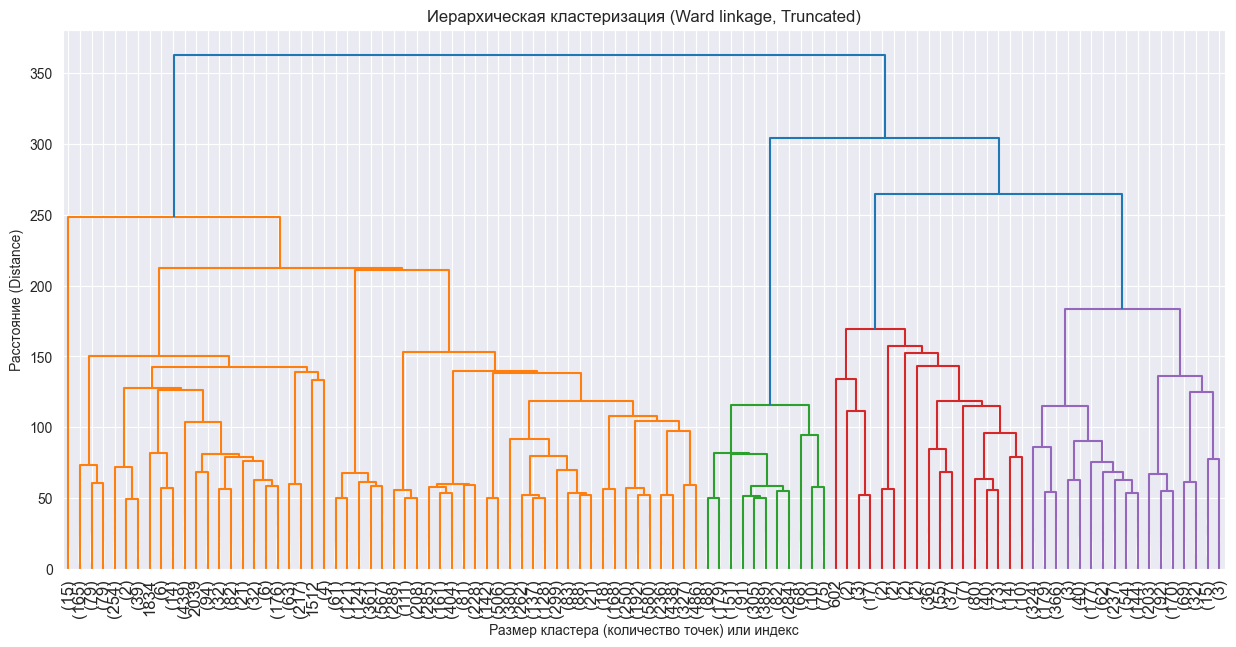

In [798]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

merging = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 7))

dendrogram(
    merging,
    truncate_mode='lastp',
    p=100,
    leaf_rotation=90,
    leaf_font_size=12,
    show_contracted=True
)

plt.title('Иерархическая кластеризация (Ward linkage, Truncated)')
plt.xlabel('Размер кластера (количество точек) или индекс')
plt.ylabel('Расстояние (Distance)')
plt.show()

In [799]:
clusters = fcluster(merging, 150, criterion='distance')
print(clusters)

[3 3 6 ... 6 3 3]


In [800]:
df['label'] = clusters
print(df.sort_values('label')['label'])

20459     1
17376     1
14000     1
14150     1
13065     1
         ..
14496    13
14497    13
14499    13
20981    13
14500    13
Name: label, Length: 13838, dtype: int32


In [801]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4)
kmeans.fit(X_scaled)
labels = kmeans.predict(X_scaled)

dict(zip(df.index, labels))

{0: np.int32(3),
 1: np.int32(1),
 4: np.int32(1),
 5: np.int32(2),
 8: np.int32(0),
 11: np.int32(1),
 12: np.int32(1),
 13: np.int32(1),
 14: np.int32(1),
 15: np.int32(1),
 16: np.int32(1),
 18: np.int32(2),
 19: np.int32(1),
 20: np.int32(1),
 22: np.int32(2),
 23: np.int32(2),
 27: np.int32(1),
 29: np.int32(1),
 30: np.int32(1),
 31: np.int32(2),
 32: np.int32(1),
 33: np.int32(1),
 35: np.int32(1),
 37: np.int32(2),
 38: np.int32(1),
 39: np.int32(3),
 40: np.int32(1),
 41: np.int32(1),
 42: np.int32(0),
 43: np.int32(1),
 44: np.int32(1),
 48: np.int32(3),
 51: np.int32(2),
 53: np.int32(2),
 54: np.int32(1),
 56: np.int32(1),
 57: np.int32(2),
 58: np.int32(1),
 59: np.int32(1),
 62: np.int32(1),
 63: np.int32(0),
 64: np.int32(0),
 65: np.int32(1),
 67: np.int32(0),
 69: np.int32(3),
 70: np.int32(2),
 71: np.int32(2),
 72: np.int32(1),
 73: np.int32(3),
 74: np.int32(1),
 75: np.int32(0),
 78: np.int32(0),
 80: np.int32(0),
 82: np.int32(1),
 83: np.int32(3),
 84: np.int32(1

In [802]:
pd.Series(labels).value_counts().sort_index()

0    1822
1    8407
2    2870
3     739
Name: count, dtype: int64

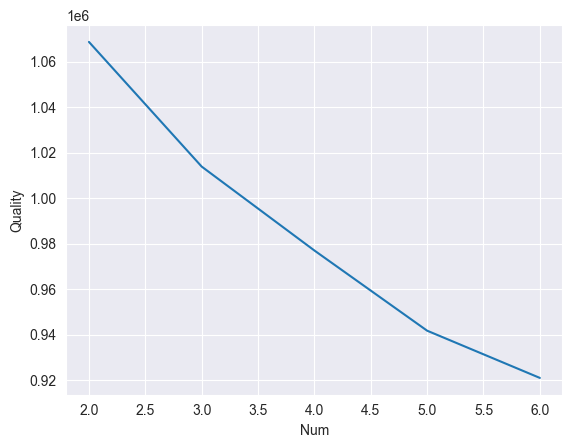

In [803]:
crit = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=15)
    kmeans.fit(X_scaled)
    crit.append(kmeans.inertia_)

plt.plot(range(2,7), crit)
plt.xlabel('Num')
plt.ylabel('Quality')
plt.show()

In [804]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X_scaled)
labels = kmeans.predict(X_scaled)

pd.DataFrame(labels, df.index)

,0
0,2
1,1
4,1
5,0
8,2
...,...
20994,0
20996,1
20997,1
20998,1


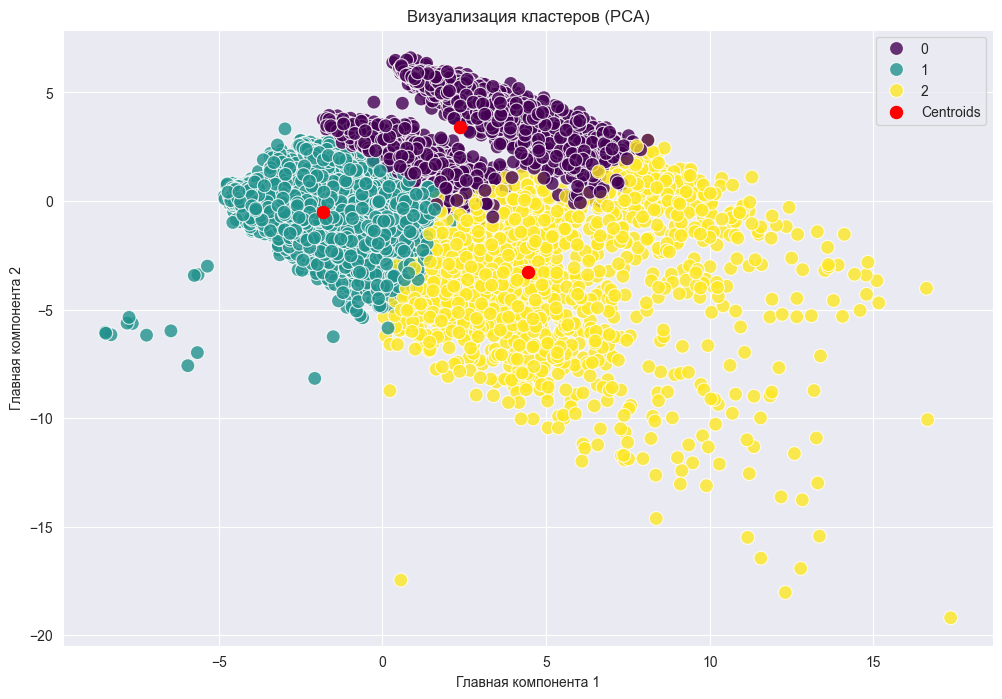

In [805]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels,
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='.',
    s=300,
    c='red',
    label='Centroids'
)

plt.title('Визуализация кластеров (PCA)')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.legend()
plt.grid(True)
plt.show()